<h2><center>Assignment 4</center></h2>
<h3><center>Programming for Data Science 2026</center></h3>
<b><center>Deadline: 14:00, March 26, 2026</center></b>

- The exercise will be marked as **passed** if you get **at least 10/16** points.

- Exercises must be handed in via **ILIAS** (Homework assignments). Submit your work as a **compressed (.zip)** file containing **one** `.py` **or** `.ipynb` file with **all exercises**.

- The name of **both** the `.zip` file and the `.py`/`.ipynb` file must be the *SurnameName* of the **two group members**, separated by an underscore.  
  Example: Tim Tabellen and Lara Lambda → `TabellenTim_LambdaLara.zip`  
  (The `.py`/`.ipynb` file must have the same name.)

- Use **comments** to explain your code and demonstrate that you understand the solutions and can discuss them.

- You are not expected to collaborate outside your group. Submitting other groups’ code as your own will result in **0 points**.

- For general questions about the lecture content, assignments, or the exam, please use the **ILIAS forum**.

- For individual questions about lecture content and the exam, contact: *roland.widmer@students.unibe.ch*  

- For individual questions about the exercises or grading, contact: *julien.brunner@students.unibe.ch* or *aline.steiner@students.unibe.ch*

#### Exercise 1: Sum of squares *(1 point)*

The code below squares and sums the numbers in the array `arr`, and holds the result in the variable `sum_of_squares`, which should be 1135.

However, that is not the case. Explain what is wrong and how we may correct it.

In [7]:
import numpy as np

arr = np.array([13, 14, 15, 16, 17], dtype=np.int8)
sum_of_squares = np.sum(arr ** 2)
print("squared array:", arr ** 2)
sum_of_squares

squared array: [-87 -60 -31   0  33]


np.int64(-145)

**Your answer:** the arr ** 2 expression still applies element-wise, but the output is not able to represent the expected values because of the data type of the element in the array, which are in this case signed integers of 8 bytes which ranges between -128 to 127 (256 values), and since each square is out of the int8 range.
There for the program wraps around to be able to produce an output, as follows 13 ** 2 = 169, and the output is 169 - 256 = -87 

#### Exercise 2: Broadcasting *(2 points)*

Reshape `scaling_factors` so it is possible to multiply `data` and `scaling_factors`, and explain why you had to reshape `data` to be able to multiply the two arrays.

`data` contains 4 trials with 2 measurement, `scaling_factors` a scaling factor for all 4 trials.

In [ ]:
import numpy as np

data = np.array([[1, 2], [4, 5], [2, 4], [1, 4]])
scaling_factors = np.array([2, 1, 2, 1])

# TODO

**Your answer**: TODO

#### Exercise 3: Base converter *(2 points)*

Write a function `int_to_bin` that takes a positive integer as input and returns the binary equivalent of that integer as a string.

You can **not** use built-in methods such as `bin()` in your solution.

Hint: The % operator could be useful to solve this exercise.

In [62]:
def int_to_bin(x: int, top_level: bool = True) -> str:
    """
    the function takes a positive integer and returns its value as binary, the top level argument is by default 
    set to True to enable an output of minimum 4-bits.

    the .zfill string method ads the additional 0 to the left of the string until it reaches a length of 4 only if
    the top level string has a length of less than 4.

    the function recursively calls itself whit the quotient of the floor division and ads the reminder as a string 
    as a new bit after each call
    """
    if x == 0:
        return "".zfill(4) if top_level else ""

    
    quotient: int = x // 2
    remainder: str = str(x % 2)
    as_bin: str = int_to_bin(quotient, top_level= False) + remainder
    #top level is then set to False to not truncate the returns for non top level argument passed to the function
    
    return as_bin.zfill(4) if top_level else as_bin
            

print("Tests:")
print("1 as binary ->",int_to_bin(1))
print("4 as binary ->",int_to_bin(4))
print("15 as binary ->",int_to_bin(15))

Tests:
1 as binary -> 0001
4 as binary -> 0100
15 as binary -> 1111


#### Exercise 4: Sales *(2 points)*

The array represents `sales` per day (in CHF). The rows represent the item, the columns the day.

Example: On Monday, item 1 has had a revenue of $120.-$

In [ ]:
sales = np.array([[120, 160, 100, 130, 170, 25, 0], [90, 115, 95, 105, 125, 3, 0]], dtype=np.float64)

Suppose a discount was applied to days, where sales exceeded $100.-$. Write a NumPy expression to get a boolean array indicating which sales values qualify for the discount.

In [ ]:
# TODO

The discount was set to be 15%. Adapt the sales according to this discount.

In [ ]:
# TODO

#### Exercise 5: Audio signal *(3 points)*

We load two sounds and define a helper function to save sounds to the `output` folder. Note that both sounds are mono and have the same sampling frequency.

In [66]:
import os

from scipy.io.wavfile import read, write

fs_bird, sound_bird = read("../data/audio/bird.wav")
fs_leaves, sound_leaves = read("../data/audio/leaves.wav")

def write_sound(sound, name="sound.wav", fs=44100):
    os.makedirs(os.path.join("..", "output"), exist_ok=True)
    write(os.path.join("..", "output", name), rate=fs, data=sound)

The two sounds do not have the same length (number of samples). Print the lengths of both sounds and create a modified version of the leaves sound that has the same length as the bird sound by cropping it (making it shorter).

In [69]:
print("Bird sound length:",len(sound_bird))
print("Leaves sound length:",len(sound_leaves))

new_sound_leaves = sound_leaves[:25824]
print("New leaves sound length:", len(new_sound_leaves))

Bird sound length: 25824
Leaves sound length: 32612
New leaves sound length: 25824


Create a silence period (0 amplitude) of the same duration of the two sounds, using NumPy.

In [91]:
import numpy as np
silence = np.zeros(25824)

Finally, concatenate the diffent sounds into a single one. The order should be: silence, birds, silence, leaves (cropped), silence. Print the shape of the concatenated sound and save the sound using `write_sound`. Listen to the sound, did it work?

In [95]:
final_sound = np.concatenate([silence , sound_bird , silence , new_sound_leaves , silence])

write_sound(final_sound)

#### Exercise 6: Owl revisited *(1 point)*

We start with the grayscale owl from the last assignment.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def load_gray_scale_image(path):
    image_data = plt.imread(path)
    image_data = np.array(image_data)
    image_data = (0.2989 * image_data[:, :, 0] + 0.5870 * image_data[:, :, 1] + 0.1140 * image_data[:, :, 2]).astype(np.uint8)
    image_data = np.stack([image_data] * 3, axis=-1)
    return image_data

def plot_image(image_data):
    plt.imshow(image_data)
    plt.show()

image_data = load_gray_scale_image("../data/images/owl.jpg")

print(image_data.shape)

plot_image(image_data)

Replace all dark pixels (value below 30) with a red color and plot it with `plot_image`.

In [ ]:
# TODO

#### Exercise 7: Aare revisited *(2 points)*

In this exercise, we work with daily water temperature data from the Aare river in Bern again. 

Source: [Hydrology Division, Federal Office for the Environment FOEN (2026)](https://www.hydrodaten.admin.ch/en/seen-und-fluesse/messstationen-temperatur).

First, we define some helper functions:

- `get_temperature_data`: returns the daily temperature data for 2004-2025
- `plot_temperature`: plots the the temperature for a given numpy array

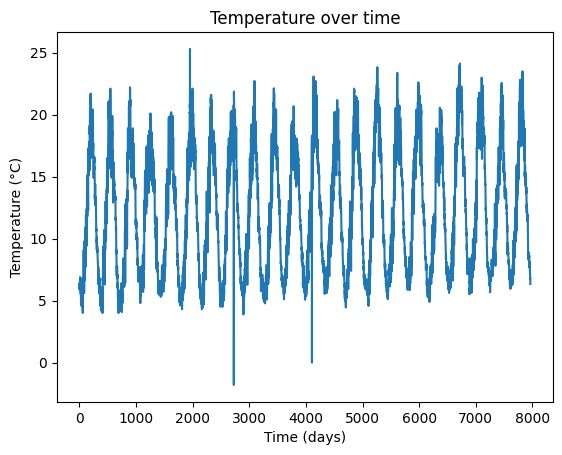

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_temperature_data():
    temperature_df = pd.read_csv(f"../data/csv/aare_temperature.csv", parse_dates=["timestamp"])
    
    return temperature_df["value"].to_numpy()



def plot_temperature(temperature_data, time_unit="days"):
    plt.plot(temperature_data)
    plt.xlabel(f"Time ({time_unit})")
    plt.ylabel("Temperature (°C)")
    plt.title(f"Temperature over time")
    plt.show()


temperature = get_temperature_data()
plot_temperature(temperature)


Count how many days were bathable (i.e., water temperature was above 18 °C). Also give the percentage of bathable days compared to all days.

In [120]:
mask = temperature >= 18
result = temperature[mask]
print("number of bathable days: ", len(result))
total_days = len(temperature)
bathable_percentage = round((len(result)/total_days) * 100, 2 )
print(f"Percentage of bathable days: {bathable_percentage}%")

number of bathable days:  1370
Percentage of bathable days: 17.2%


Set the temperature of all 'non-bathable' days to `np.nan`. Calculate the mean temperature of remaining days.

In [125]:
mask = temperature >= 18
temperature = temperature.astype(float)
temperature[~mask] = np.nan
print("Mean of non nan values =", round(np.nanmean(temperature), 2) )

Mean of non nan values = 19.83


#### Exercise 8: Vacation recommendations *(3 points)*

The code below defines five vacation destinations (`locations`) and four attributes for each (`attributes`). Each row describes one destination, and the columns represent scores on the factors scenery, activities, food, and nightlife.

Write a function `vacation_advisor` that asks the user whether they find each of the attributes important or not, and suggests the best vacation spot based on these preferences. If the user inputs `n` for all of the questions, print a message and ask again. Use techniques from the lecture to solve the exercise.

Hints:
- Translate the preferences (i.e., y/n) into a binary vector.
- Select attributes using the preferences to calculate a score per country.
- If multiple countries have the same score, return the first one.

Example interaction:
```raw
Is scenery important to you [y/n]?    > y
Is activities important to you [y/n]? > y
Is food important to you [y/n]?       > n
Is nightlife important to you [y/n]?  > n
Based on your preferences, the best destination is Australia
```

In [ ]:
locations = np.array([ "Hawaii", "Thailand", "Italy", "Australia", "Japan"])

# List of attributes for each destination. Each column is an attribute. Each row a destination.
attributes = np.array([
    [8, 8, 7, 6],
    [7, 9, 8, 7],
    [8, 6, 9, 7],
    [9, 8, 8, 6],
    [7, 9, 7, 8]
])

# Declare attribute names and initialize boolean array with preferences
attribute_names = ["scenery", "activities", "food", "nightlife"]

In [ ]:
# TODO